In [2]:
from typing import Annotated
from gen_ai_hub.proxy.langchain.openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [4]:
load_dotenv()
llm=ChatOpenAI(proxy_model_name='gpt-4o')


True

In [5]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [12]:
def chat_node(state:ChatState):
    decision=interrupt({
        "type":"approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"

    })
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}
    

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}

In [11]:
graph=StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

checkpointer=MemorySaver()
app=graph.compile(checkpointer=checkpointer)


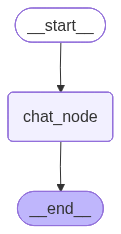

In [9]:
app

In [13]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

KeyError: 'messages'